In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [2]:
ENV_NAME = 'cheetah' # cheetah | walker

In [3]:
NUM_TRAJECTORIES = 10000
TRAJECTORY_LEN = 1000

KEEP_ONLY_COORDS = False

In [4]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
from dm_control import suite

if ENV_NAME == 'cheetah':
    STATE_DIM = 18
    ACTION_DIM = 6
    AUX_DIM = 1
    env = suite.load(
        domain_name='cheetah',
        task_name='run',
        environment_kwargs=dict(flat_observation=True)
    )
    dataset = np.load('datasets/cheetah_rnd.npy', allow_pickle=True).item()
    aux = np.load('datasets/aux_cheetah.npy')
    dataset['observations'] = np.concatenate((dataset['observations'], aux.reshape(10000, 1000, 1)), axis=-1)
    
else:
    STATE_DIM = 27
    ACTION_DIM = 6
    AUX_DIM = 3
    env = suite.load(
        domain_name='walker',
        task_name='walk',
        environment_kwargs=dict(flat_observation=True)
    )
    dataset = np.load('datasets/walker_rnd.npy', allow_pickle=True).item()
    aux = np.load('datasets/aux_walker.npy')
    dataset['observations'] = np.concatenate((dataset['observations'], aux.reshape(10000, 1000, 3)), axis=-1)

/home/nazim/.local/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn
/home/nazim/.local/lib/python3.10/site-packages/mujoco_py/builder.py:9: DeprecationWarning: The distutils.sysconfig module is deprecated, use sysconfig instead
  from distutils.sysconfig import customize_compiler
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28


In [5]:
dataset_trajectories = torch.tensor(dataset['observations']).float()
dataset_trajectories = dataset_trajectories
# dataset_trajectories = torch.concatenate((dataset_trajectories[..., [0, 1]], dataset_trajectories[..., [15, 16]]), dim=-1)

dataset_actions = torch.tensor(dataset['actions']).float()
dataset_terminals = torch.tensor(dataset['terminals']).float()
dataset_timeouts = torch.zeros(NUM_TRAJECTORIES, TRAJECTORY_LEN).bool()
dataset_timeouts[:, -1] = True

dataset_goals = torch.tensor(dataset['infos/goal']).float()



dataset_trajectories = dataset_trajectories.reshape(-1, TRAJECTORY_LEN, STATE_DIM)
dataset_actions = dataset_actions.reshape(-1, TRAJECTORY_LEN, ACTION_DIM)
dataset_terminals = dataset_terminals
dataset_timeouts = dataset_timeouts.reshape(-1, TRAJECTORY_LEN)


num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape

In [6]:
dataset_mean = dataset_trajectories.mean([0, 1])
dataset_std = dataset_trajectories.std([0, 1])


def normalize_dataset_coords(dataset_):
    return dataset_

def denormalize_dataset_coords(dataset_):
    return dataset_

dataset_trajectories = normalize_dataset_coords(dataset_trajectories)
dataset_trajectories_cuda = dataset_trajectories.to(device)


In [7]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create a long enough PEs tensor
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # (1, max_len, d_model) so it can be broadcast over batch
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]  # match seq_len
        return self.dropout(x)


In [8]:
class FRENetwork(nn.Module):
    def __init__(self, state_dim, action_dim, num_heads=2, num_layers=2, d_model=128):
        super().__init__()
        
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.d_model = d_model
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.d_model, 
                num_heads, 
                dim_feedforward=4*self.d_model, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.d_model, self.d_model)
        self.encoder_log_std = nn.Linear(self.d_model, self.d_model)

        self.state_embed = nn.Linear(self.state_dim, self.d_model // 2)
        self.action_embed = nn.Linear(self.action_dim, self.d_model // 2)

        self.action_predict = nn.Sequential(
            nn.Linear(self.state_dim + self.d_model, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, action_dim),
            nn.Tanh()
        )
        
        self.positional_encoding = PositionalEncoding(d_model=d_model, dropout=0.1, max_len=200)



    def get_transformer_encoding(self, states, actions, pad_mask):  
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=states.device)
        # pad_mask.shape = [batch, anchors]
                
        state_emb = self.state_embed(states)
        action_emb = self.action_embed(actions)
        
        state_action_emb = torch.concat([state_emb, action_emb], dim=-1)
        
        x = self.positional_encoding(state_action_emb)
        w_pre = self.encoder_transformer(x, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_action_pred(self, w, states): # Reward Pairs: [batch, seq, obs_dim]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, states], axis=-1)
        
        reward_pred = self.action_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

# FRE:

In [9]:
class MLPRewards:
    def __init__(self, N, obs_len):

        self.N = N
        
        self.param_w1 = torch.normal(0, 1, size=(self.N, obs_len, 32)) * np.sqrt(1/32)
        self.param_b1 = torch.normal(0, 1, size=(self.N, 1, 32)) * np.sqrt(16)
        self.param_w2 = torch.normal(0, 1, size=(self.N, 32, 1)) * np.sqrt(1/16)
        
        if obs_len == 18:
            self.param_w1[:, -1:] = 0
        elif obs_len == 27:
            self.param_w1[:, -3:] = 0
            
    
    def sample(self, N):
        return torch.randint(0, self.N, (N,))

    def __call__(self, obs, param_id=None):
        """
        obs.shape = (batch_size, num_samples, obs_dim)
        param_id.shape = (batch_size, 1)
        """
        
        batch_size, num_samples, obs_dim = obs.shape
        batch_size_, _ = param_id.shape
        assert (batch_size == batch_size_)
        
        device = obs.device
        
        if param_id is None:
            param_id = torch.randint(0, self.N, size=(obs.shape[0], 1))
        
        param_id_expanded = param_id.repeat(1, obs.shape[1]).cpu()
        param1_w = self.param_w1[param_id_expanded].to(device)
        param1_b = self.param_b1[param_id_expanded].to(device)
        param2_w = self.param_w2[param_id_expanded].to(device)

        # obs[..., 2:] = 0.0

        x = torch.unsqueeze(obs, -2) # [batch, (pairs), 1, features_in]
        x = torch.matmul(x, param1_w) # [batch, (pairs), 1, features_out]
        x = x + param1_b
        x = torch.tanh(x)
        r = torch.matmul(x, param2_w) # [batch, (pairs), 1, 1]
        r = r.squeeze(-1).squeeze(-1) # [batch, (pairs)]
        r = torch.clip(r, -1, 1)

        return r, param_id
    
# mlp_rewards = MLPRewards(N=10000, obs_len=29)

In [10]:
class LinearRewards:
    def __init__(self, N, obs_len):

        self.N = N
        
        self.param_w1 = torch.rand(size=(self.N, obs_len, 1)) * 2 - 1
        self.random_mask = torch.rand(size=(self.N, obs_len)) < 0.9
        # self.random_mask[..., :2] = True
        
        random_mask_positive = np.random.randint(2, obs_len, size=(N,))
        self.random_mask[np.arange(N), random_mask_positive] = False # Force at least one positive weight.
        
        if obs_len == 18:
            self.param_w1[:, -1:] = 0
        elif obs_len == 27:
            self.param_w1[:, -3:] = 0
            
            
            
        

    def sample(self, N):
        return torch.randint(0, self.N, (N,))

    def __call__(self, obs, param_id=None):
        """
        obs.shape = (batch_size, num_samples, obs_dim)
        param_id.shape = (batch_size, 1)
        """
        
        batch_size, num_samples, obs_dim = obs.shape
        batch_size_, _ = param_id.shape
        assert (batch_size == batch_size_)
        
        device = obs.device
        
        if param_id is None:
            param_id = torch.randint(0, self.N, size=(obs.shape[0], 1))
        
        param_id_expanded = param_id.repeat(1, obs.shape[1]).cpu()
        param1_w = self.param_w1[param_id_expanded].to(device)
        mask = self.random_mask[param_id_expanded].to(device)
        obs = (~mask) * obs
        
        x = torch.unsqueeze(obs, -2) # [batch, (pairs), 1, features_in]
        r = torch.matmul(x, param1_w) # [batch, (pairs), 1, features_out]
        r = r.squeeze(-1).squeeze(-1) # [batch, (pairs)]
        r = torch.clip(r, -1, 1)

        return r, param_id

In [11]:
class GoalRewards:
    def __init__(self):
        pass
    
    def sample_goals(self, N):
        goals = dataset_trajectories[
            torch.randint(0, num_trajectories, (N,)),
            torch.randint(0, len_trajectory, (N,)),
        ]
        return goals
    
    # def get_states(self, num_states, goals):
    #     cond = (dataset_trajectories[..., :2] - goal[..., :2]).norm(dim=-1) < 0.5
    #     dataset_trajectories_cuda[cond][torch.randint(0, cond.sum(), (1,))]
    
    def __call__(self, obs, goals=None):
        """
        obs.shape = (batch_size, num_samples, obs_dim)
        param.shape = (batch_size, obs_dim)
        """
        
        if obs.shape[-1] == 18:
            std = torch.tensor([[0.4407440506721877, 10.070289916801876, 0.5172332956856273, 0.5601041145815341, 0.518947027289748, 0.3204431592542281, 0.5501848643154092, 0.3856393812067661, 1.9882502334402663, 1.6377168569884073, 4.308505013609855, 12.144181770553105, 13.537567521831702, 16.88983033626308, 7.715009572436841, 14.345667964212357, 10.6904255152284, 100]])
        elif obs.shape[-1] == 27:
            std = torch.tensor([[0.7212967364054736, 0.6775020895964047, 0.7638155887842976, 0.6395721376821286, 0.6849394775886244, 0.7078581708129903, 0.7113168519036742, 0.6753408522523937, 0.6818095329625652, 0.7133958718133511, 0.65227578338642, 0.757622576816855, 0.7311826446274479, 0.6745824928740024, 0.36822491550384456, 2.1134839667805805, 1.813353841099317, 10.594648894374815, 17.41041469033713, 17.836743227082106, 22.399097178637533, 16.1492222730888, 15.693574546557201, 18.539929326905067, 100, 100, 100]])

        
        batch_size, num_samples, obs_dim = obs.shape
        batch_size_, obs_dim_ = goals.shape
        assert (batch_size == batch_size_) and (obs_dim == obs_dim_)
        
        device = obs.device
        
        goals = goals.to(device)

        # r = torch.norm(obs - goals.unsqueeze(-2), dim=-1) < 2
        dists_per_dim = obs - goals.unsqueeze(-2)
        dists_per_dim = dists_per_dim / std.to(device)
        dists = torch.norm(dists_per_dim, dim=-1) / obs.shape[-1]
        r = (dists < 0.2)
        r = r.float() * 2 - 1
        r = torch.clip(r, -1, 1)

        return r, goals


In [12]:
linear_rewards = LinearRewards(N=10000, obs_len=STATE_DIM)
mlp_rewards = MLPRewards(N=10000, obs_len=STATE_DIM)
goal_rewards = GoalRewards()

In [65]:
def sample_reward_function_fre(batch_size, num_random_samples):

    trajectories_idx = torch.randint(0, num_trajectories, (batch_size*num_random_samples,))
    states_idx = torch.randint(0, len_trajectory, (batch_size*num_random_samples,))
    random_states = dataset_trajectories[trajectories_idx, states_idx] # get the random states
    random_states = random_states.reshape(batch_size, num_random_samples, STATE_DIM).to(device)

    reward_params = torch.zeros((batch_size, 128))
    random_states_rewards = torch.zeros((batch_size, num_random_samples))

    for b in range(batch_size):
        # reward_type = torch.randint(0, 3, (1,)) # 0: goal_reaching | 1: linear_reward | 2: mlp_reward
        # reward_type = torch.randint(1, 3, (1,))   # 1: linear_reward | 2: mlp_reward
        
        reward_type = 1
        
        reward_params[b, 0] = reward_type
        if reward_type == 0:
            goal = goal_rewards.sample_goals(1)
            goal = goal.repeat(1, 1)
            r, param_id = goal_rewards(random_states[[b]], goals=goal)    
            reward_params[b, 1:1+obs_dim] = param_id
            random_states[b, 0] = goal
            r[0, 0] = 1.
            
        elif reward_type == 1:
            param_id = linear_rewards.sample(1).unsqueeze(0)
            r, param_id = linear_rewards(random_states[[b]], param_id)
            reward_params[b, 1] = param_id
            
        elif reward_type == 2:
            param_id = mlp_rewards.sample(1).unsqueeze(0)
            r, param_id = mlp_rewards(random_states[[b]], param_id) 
            reward_params[b, 1] = param_id
            
        random_states_rewards[b] = r
        
    return reward_params, random_states, random_states_rewards

In [66]:
# reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=4, num_random_samples=10000)

# for b in range(4):

#     # plt.scatter(random_states[b, :, 16].cpu(), random_states[b, :, 24].cpu(), c=random_states_rewards[b], vmin=-1, vmax=1)
    
#     # sorted_ids = random_states[b, :, 17].cpu().argsort()
#     # plt.plot(random_states[b, :, 17][sorted_ids].cpu(), random_states_rewards[b][sorted_ids])
    
#     plt.show()
    
#     break

# Reward Generator:

In [67]:
EPISODE_LENGTH = TRAJECTORY_LEN
Z_DIM = 128
MIN_NUM_ANCHORS = 2
MAX_NUM_ANCHORS = 4

In [169]:
class RewardGeneratorTransformer(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=Z_DIM):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim // 2)
        self.reward_embed = nn.Embedding(self.num_discrete_embeddings, self.reward_pairs_emb_dim // 2)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 1),
            nn.Tanh()
        )



    def get_transformer_encoding(self, states, rewards, pad_mask):  
        
        if ENV_NAME == 'cheetah':
            states[..., -1:] = 0
        elif ENV_NAME == 'walker':
            states[..., -3:] = 0
        
        mask = (states != 0).float()
        states = normalize_dataset_coords(states)
        states = states * mask
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=device)
        # pad_mask.shape = [batch, anchors]
        
        # reward_values_idx = torch.floor(rewards * self.num_discrete_embeddings).int()
        reward_values_idx = torch.floor((rewards*0.5+0.5) * self.num_discrete_embeddings).int() # dont forget that rewards are in [-1, 1]
        reward_values_idx = torch.clip(reward_values_idx, 0, self.num_discrete_embeddings - 1)

        
        state_emb = self.state_embed(states)
        reward_emb = self.reward_embed(reward_values_idx.squeeze(-1))
        state_reward_emd = torch.concat((state_emb, reward_emb), dim=-1)
        
        w_pre = self.encoder_transformer(state_reward_emd, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)
        
        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
                        
        if ENV_NAME == 'cheetah':
            reward_states[..., -1:] = 0
        elif ENV_NAME == 'walker':
            reward_states[..., -3:] = 0
        
        mask = (reward_states != 0).float()
        reward_states = normalize_dataset_coords(reward_states)
        reward_states = reward_states * mask
        
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]

In [170]:
class RewardGenerator:
    def __init__(self, fre_network: RewardGeneratorTransformer):
        
        self.fre_network = fre_network.to(device)
        self.optimimizer = torch.optim.Adam(self.fre_network.parameters(), lr=0.001)
        
        self.len_params = Z_DIM
        self.resampling_weights = None
        
    
    def get_reward(self, obs, w):
        self.fre_network.eval()
        
        # obs.shape == (batch_size, obs_len)
        # w.shape == (batch_size, w_dim)
        assert obs.shape[0] == w.shape[0]
        assert len(obs.shape) == 2
        
        obs = obs.unsqueeze(1)
        with torch.no_grad():
            rewards_pred = self.fre_network.get_reward_pred(w, obs)
        
        return rewards_pred.reshape(-1, 1)
    
    
    def get_training_data(self, batch_size, min_num_anchors, max_num_anchors):
        assert min_num_anchors <= max_num_anchors

        obs_dim = dataset_trajectories.shape[-1]
        

        # buffer = dataset_trajectories[..., :2].reshape(-1, 2)
        # buffer = dataset_trajectories
        
        anchors = torch.zeros((batch_size, max_num_anchors, obs_dim), dtype=torch.float32)

        
        trajectories_idx = torch.randint(0, num_trajectories, (batch_size*max_num_anchors,))
        states_idx = torch.randint(0, 100, (batch_size*max_num_anchors,))
        anchors = dataset_trajectories[trajectories_idx, states_idx]
        anchors = anchors.reshape(batch_size, max_num_anchors, obs_dim)

            
        anchors_rewards = torch.zeros((batch_size, max_num_anchors), dtype=torch.float32)
        pad_mask = torch.ones((batch_size, max_num_anchors), dtype=torch.bool)

        # Generate random number of anchors for each batch element
        num_anchors = torch.randint(min_num_anchors, max_num_anchors + 1, (batch_size,))

        reward_indices = torch.arange(max_num_anchors).unsqueeze(0)
        reward_mask = reward_indices < num_anchors.unsqueeze(1)

        
        # candidates = torch.tensor([-1, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.])
        
        reward_types = torch.ones((batch_size,), dtype=torch.long) # 0: goal reaching | 1: MLP
        
        candidates = [
            # torch.tensor([-1, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.]),
            torch.tensor([-1, -0.5, 0.0, 0.5, 1.]),
            # torch.tensor([-1, -0.75, -0.5, -0.25, 0.0]),
            # torch.tensor([0.0, 0.25, 0.5, 0.75, 1.]),
        ]
        res = []
        for b in range(batch_size):
            x = torch.randint(0, len(candidates), (1,))
            res.append(candidates[x][torch.randint(0, candidates[x].shape[0], (max_num_anchors,))])
        anchors_rewards = torch.stack(res)
        
        # anchors_rewards[reward_mask] = candidates[torch.randint(0, candidates.shape[0], (reward_mask.sum(),))]
        
        # Goal reaching reward functions:
        # random_rows = torch.tensor([n for n in range(batch_size) if random.random() < 0.3], dtype=torch.long)
        # anchors_rewards[random_rows] = -1.
        # anchors_rewards[random_rows, 0] = 1.
        # reward_types[random_rows] = 0

            
        # rewards[reward_mask] = torch.exp(2*(rewards[reward_mask] - 1))
        anchors_rewards = anchors_rewards.unsqueeze(-1)

        pad_mask_indices = torch.arange(max_num_anchors).unsqueeze(0)
        pad_mask = pad_mask_indices < num_anchors.unsqueeze(1)
        pad_mask = ~pad_mask
                
        
        anchors = anchors.float()
        anchors_rewards = anchors_rewards.float()
        pad_mask = pad_mask
        
        return (anchors, anchors_rewards, pad_mask), {'reward_types':reward_types}
    

    def generate_boolean_mask(self, batch_size, length, p=0.9):
        vecs = (torch.rand(batch_size, length) > p).bool()
        mask = ~vecs.any(dim=1)
        if mask.any():
            rows = mask.nonzero(as_tuple=False).squeeze(1)
            cols = torch.randint(0, length, (rows.size(0),))
            vecs[rows, cols] = True
        
        
        if KEEP_ONLY_COORDS:
            vecs = torch.zeros_like(vecs)
            vecs[:, :2] = True
            
        return vecs * 1.
    
        
    def train_step_VAE(self, batch_size, min_num_anchors, max_num_anchors):
        self.fre_network.train()
        
        (anchors, anchors_rewards, pad_mask), info = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)
        
        mask = self.generate_boolean_mask(batch_size, STATE_DIM, p=0.9)
        # mask = torch.zeros_like(mask)
        # mask[..., [0, 1]] = 1


        mask = mask.unsqueeze(1).repeat(1, max_num_anchors, 1)
        mask = mask.to(device)
        anchors = anchors * mask
                                

        w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask=pad_mask)
        
        
        
        w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
        # w = w_mean
        rewards_pred = self.fre_network.get_reward_pred(w, anchors)
        
        
        reward_pred_loss = ((rewards_pred[~pad_mask] - anchors_rewards[~pad_mask])**2).mean()
                        
        
        kl_loss = -0.5 * (1 + 2*w_log_std - w_mean**2 - torch.exp(w_log_std)**2).mean()
        loss = reward_pred_loss + kl_loss * 0.01
        
        
        self.optimimizer.zero_grad()
        loss.backward()
        self.optimimizer.step()
        
        return {
            'loss': loss.item(),
            'reward_pred_loss': reward_pred_loss.item(),
            'kl_loss': kl_loss.item(),
            'get_training_data:info': info,
            'anchors': anchors.cpu(),
            'anchors_rewards': anchors_rewards.cpu(),
            'pad_mask': pad_mask.cpu(),
        }
        
    
    def get_z_from_random_anchors(self, batch_size: int, min_num_anchors:int, max_num_anchors:int, mask=None):
        self.fre_network.eval()
        
        (anchors, anchors_rewards, pad_mask), info = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)
        
        if mask is None:
            mask = self.generate_boolean_mask(batch_size, STATE_DIM, p=0.0)
        
        assert mask.shape == (batch_size, STATE_DIM)
        
        mask = mask.unsqueeze(1).repeat(1, max_num_anchors, 1)
        mask = mask.to(device)
        anchors = anchors * mask
        
        eval_z, _ = self.get_z_from_anchors(anchors, anchors_rewards, pad_mask)
        
        return eval_z, {
            'anchors': anchors.cpu(), 
            'anchors_rewards': anchors_rewards.cpu(), 
            'pad_mask': pad_mask.cpu(), 
            'get_training_data:info': info
        }
    

    def get_z_from_anchors(self, anchors: torch.Tensor, anchors_rewards: torch.Tensor, pad_mask: torch.Tensor):    
        assert anchors.shape[:-1] == pad_mask.shape
        self.fre_network.eval()
        
        batch_size = anchors.shape[0]
        
        with torch.no_grad():
            w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask) 
        
        # eps = torch.normal(0, 1, (batch_size, self.emperical_mean.shape[0]), device=device)
        # z = w_mean + eps * torch.exp(w_log_std)
        z = w_mean
        
        return z, {'anchors': anchors.cpu()}


In [171]:
num_anchors = 8

rg_model = RewardGeneratorTransformer(obs_len=obs_dim)
# rg_model.load_state_dict(torch.load('models/all_in_one-coords-rg_model.pth'))
# rg_model.load_state_dict(torch.load('shared_models/offline_fre+reward_generator-rg_model.pth'))

reward_generator = RewardGenerator(
    fre_network=rg_model,
)


vae_loss, vae_kl_loss = [], []

In [172]:
print('VAE training...')
for step in tqdm(range(15_000), desc='VAE training', leave=False):
    
    vae_loss_dict = reward_generator.train_step_VAE(
        batch_size=256,
        min_num_anchors=MIN_NUM_ANCHORS,
        max_num_anchors=MAX_NUM_ANCHORS,
    )
    vae_loss.append(vae_loss_dict['loss'])
    vae_kl_loss.append(vae_loss_dict['kl_loss'])   
    
    # break
    
    if step % 100 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        axs[0].plot(vae_loss)
        axs[0].set_ylim([0, 0.5])
        # axs[0].set_xscale('log')
        axs[1].plot(vae_kl_loss)
        axs[1].set_ylim([0, 1])
        plt.show()
    # break

KeyboardInterrupt: 

In [185]:
def sample_reward_function_fre_RG(batch_size, num_random_samples):

    trajectories_idx = torch.randint(0, num_trajectories, (batch_size*num_random_samples,))
    # states_idx = torch.randint(0, len_trajectory, (batch_size*num_random_samples,))
    states_idx = torch.randint(0, 1000, (batch_size*num_random_samples,))

    random_states = dataset_trajectories[trajectories_idx, states_idx] # get the random states
    random_states = random_states.reshape(batch_size, num_random_samples, STATE_DIM).to(device)

    reward_params = torch.zeros((batch_size, 128))
    random_states_rewards = torch.zeros((batch_size, num_random_samples))


    # num_anchors = 16
    mask = reward_generator.generate_boolean_mask(batch_size, STATE_DIM, p=0.9)
    # mask = torch.zeros_like(mask)
    # mask[..., [0, 1]] = 1
    

    with torch.no_grad():
        reward_params, _ = reward_generator.get_z_from_random_anchors(batch_size, min_num_anchors=MIN_NUM_ANCHORS, max_num_anchors=MAX_NUM_ANCHORS, mask=mask)
        
        x = random_states * mask.unsqueeze(1).repeat(1, num_random_samples, 1).to(device)
        
        random_states_rewards = reward_generator.get_reward(
            x.reshape(-1, obs_dim), 
            reward_params.unsqueeze(1).repeat(1, num_random_samples, 1).reshape(-1, 128)
        ).reshape(batch_size, num_random_samples)
    
    return reward_params, random_states, random_states_rewards, mask

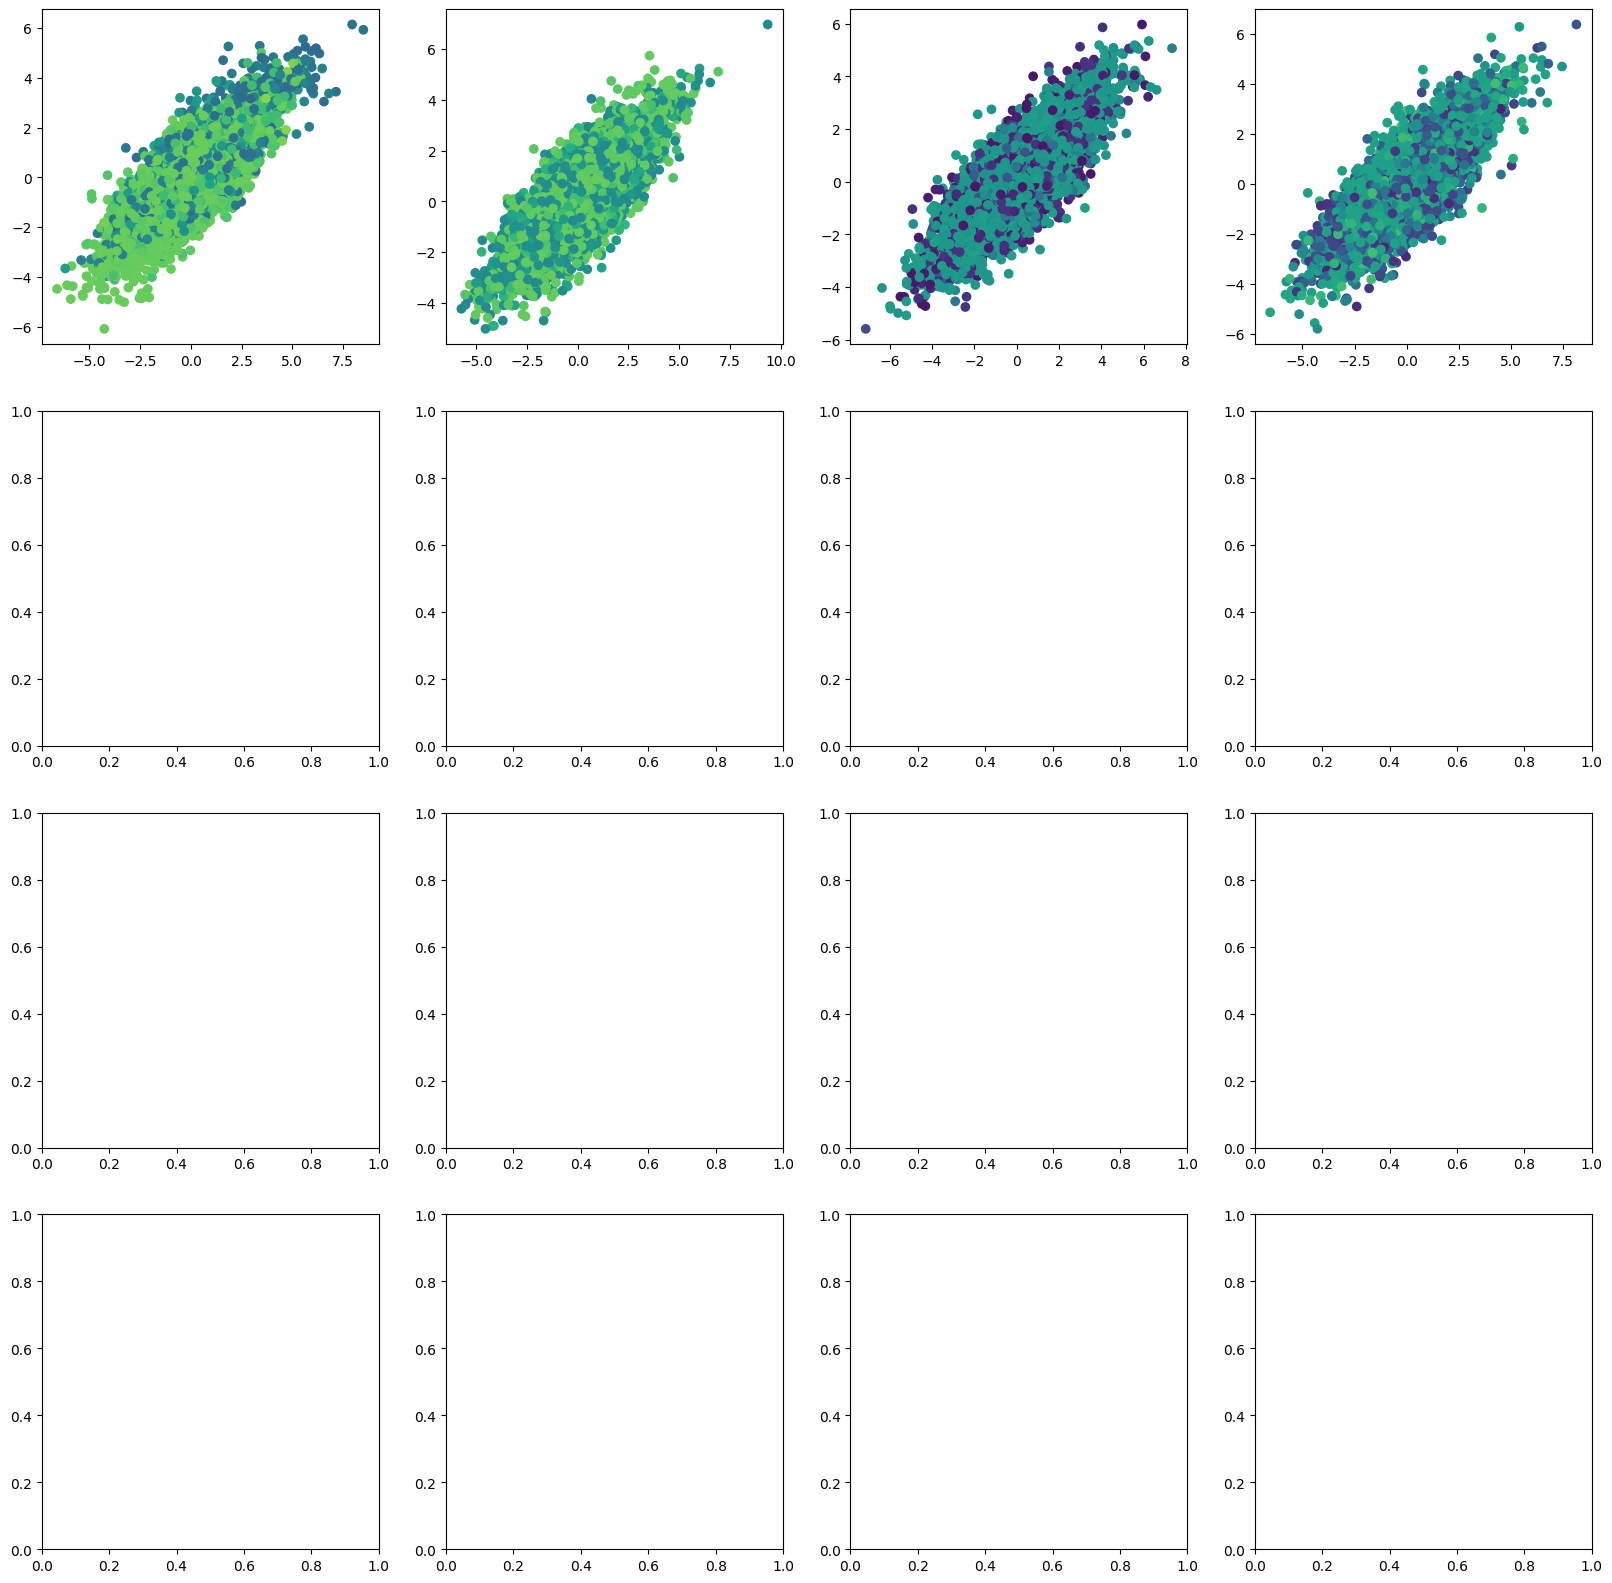

In [186]:
fig, axs = plt.subplots(4, 4, figsize=(20, 20))
axs = axs.flatten()

reward_params, random_states, random_states_rewards, mask = sample_reward_function_fre_RG(batch_size=4, num_random_samples=10000)

for b in range(4):
    axs[b].scatter(random_states[b, :, 8].cpu(), random_states[b, :, 17].cpu(), c=random_states_rewards[b].cpu(), vmin=-1, vmax=1)

# FRE:

In [188]:
class FRENetwork(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=128):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.reward_embed = nn.Embedding(self.num_discrete_embeddings, self.reward_pairs_emb_dim // 2)
        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim // 2)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 1),
        )


    def get_transformer_encoding(self, reward_state_pairs):
        reward_states = reward_state_pairs[:, :, :-1]
        reward_values = reward_state_pairs[:, :, -1]
        reward_values_idx = torch.floor((reward_values / 2.0 + 0.5) * self.num_discrete_embeddings).int()
        reward_values_idx = torch.clip(reward_values_idx, 0, self.num_discrete_embeddings - 1)

        
        reward_state_emb = self.state_embed(reward_states)
        reward_state_val = self.reward_embed(reward_values_idx)
        
        reward_state_pairs = torch.concatenate([reward_state_emb, reward_state_val], axis=-1)

        w_pre = self.encoder_transformer(reward_state_pairs) # [batch, reward_pairs, emb_dim]
        
        w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

In [189]:
fre_network = FRENetwork(obs_len=obs_dim).to(device)
# fre_network.load_state_dict(torch.load('shared_models/offline_fre-fre_network.pth'))
optimimizer = torch.optim.Adam(fre_network.parameters(), lr=0.001)

reward_losses = []
kl_losses = []

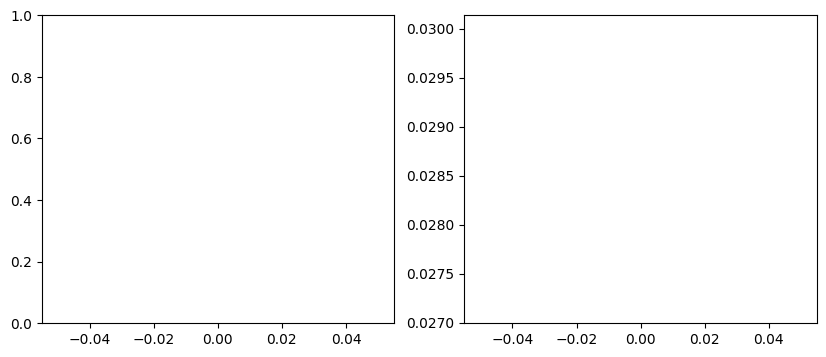

  0%|          | 19/10000 [00:02<22:50,  7.28it/s]


KeyboardInterrupt: 

In [124]:
num_encode_states = 128
num_decode_states = 128

for i in tqdm(range(10_000)):
    
    reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=256, num_random_samples=(num_encode_states+num_decode_states))
    
    encode_obs = random_states[:, :num_encode_states, :].to(device)
    decode_obs = random_states[:, num_encode_states:, :].to(device)
    
    encode_rewards = random_states_rewards[:, :num_encode_states, None].to(device)
    decode_rewards = random_states_rewards[:, num_encode_states:, None].to(device)

            
    # encode_rewards, goals = goal_rewards(encode_obs, goals=None)
    # decode_rewards, goals = goal_rewards(decode_obs, goals=goals)
    
    reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)
    
    w_mean, w_log_std = fre_network.get_transformer_encoding(reward_state_pairs)
    
    
    # Calculate the loss:
    
    w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
    # w = w_mean
    rewards_pred = fre_network.get_reward_pred(w, decode_obs)
    
    reward_pred_loss = ((rewards_pred - decode_rewards)**2).mean()
    kl_loss = -0.5 * (1 + w_log_std - w_mean**2 - torch.exp(w_log_std)).mean()
    loss = reward_pred_loss + kl_loss * 0.01
    
    optimimizer.zero_grad()
    loss.backward()
    optimimizer.step()
    
    reward_losses.append(reward_pred_loss.item())
    kl_losses.append(kl_loss.item())
    
    if i % 20 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        axs[0].plot(reward_losses)
        # axs[0].set_xscale('log')
        axs[0].set_ylim(0, 1.0)
        axs[1].plot(kl_losses)
        plt.show()
        
    # break


In [23]:
# torch.save(fre_network.state_dict(), 'models/offline_fre-fre_network.pth')

In [190]:
class VelocityRewardFunctionCheetah:
    def __init__(self):
        pass    
    
    def _sigmoids(self, x, value_at_1, sigmoid):
        if sigmoid == 'linear':
            scale = 1-value_at_1
            scaled_x = x*scale
            return np.where(abs(scaled_x) < 1, 1 - scaled_x, 0.0)
        else:
            raise NotImplementedError
    
    def tolerance(self, x, lower, upper, margin=0.0, sigmoid='linear', value_at_margin=0):
        in_bounds = np.logical_and(lower <= x, x <= upper)
        d = np.where(x < lower, lower - x, x - upper) / margin
        value = np.where(in_bounds, 1.0, self._sigmoids(d, value_at_margin, sigmoid))
        return value
    
    def compute_reward(self, states, params):
        
        if isinstance(params, int):
            params = torch.full((*states.shape[:-1], 1), fill_value=params)
        
        assert len(states.shape) == len(params.shape), states.shape # (batch_size, obs_dim) OR (batch_size, num_pairs, obs_dim)

        horizontal_velocity = states[..., 17:18]
        sign_of_param = np.sign(params)
        horizontal_velocity = horizontal_velocity * sign_of_param
        rew = self.tolerance(horizontal_velocity,
                             lower=np.abs(params),
                             upper=float('inf'),
                             margin=np.abs(params),
                             value_at_margin=0,
                             sigmoid='linear')
        
        return torch.tensor(rew[..., 0])
    
    
    
class VelocityRewardFunctionWalker:
    def __init__(self):
        pass    

    def _sigmoids(self, x, value_at_1, sigmoid):
        if sigmoid == 'gaussian':
            scale = np.sqrt(-2 * np.log(value_at_1))
            return np.exp(-0.5 * (x*scale)**2)

        elif sigmoid == 'linear':
            scale = 1-value_at_1
            scaled_x = x*scale
            return np.where(abs(scaled_x) < 1, 1 - scaled_x, 0.0)
    
    def tolerance(self, x, lower, upper, margin=0.0, sigmoid='gaussian', value_at_margin=0.1):
        in_bounds = np.logical_and(lower <= x, x <= upper)
        d = np.where(x < lower, lower - x, x - upper) / margin
        value = np.where(in_bounds, 1.0, self._sigmoids(d, value_at_margin, sigmoid))
        return torch.tensor(value)
    
    def compute_reward(self, states, params):
        
        if isinstance(params, int) or isinstance(params, float):
            params = torch.full((*states.shape[:-1], 1), fill_value=params)
        
        assert len(states.shape) == len(params.shape), states.shape # (batch_size, obs_dim) OR (batch_size, num_pairs, obs_dim)

        _STAND_HEIGHT = 1.2
        horizontal_velocity = states[..., 24:25]
        torso_upright = states[..., 25:26]
        torso_height = states[..., 26:27]
        standing = self.tolerance(torso_height, lower=_STAND_HEIGHT, upper=float('inf'), margin=_STAND_HEIGHT/2)
        upright = (1 + torso_upright) / 2
        stand_reward = (3*standing + upright) / 4
        move_reward = self.tolerance(horizontal_velocity,
                                        lower=params,
                                        upper=float('inf'),
                                        margin=params/2,
                                        value_at_margin=0.5,
                                        sigmoid='linear')
        # move_reward[params == 0] = stand_reward[params == 0]
        # rew = stand_reward * (5*move_reward + 1) / 6
        rew = (5*move_reward + 1) / 6
        
        return torch.tensor(rew[..., 0])



if ENV_NAME == 'cheetah':
    velocity_reward_function = VelocityRewardFunctionCheetah()
    benchmarks = [
        (velocity_reward_function.compute_reward, 'vel10Back', -10),
        (velocity_reward_function.compute_reward, 'vel2Back', -2),
        (velocity_reward_function.compute_reward, 'vel2', 2),
        (velocity_reward_function.compute_reward, 'vel10', 10),
    ]
elif ENV_NAME == 'walker':
    velocity_reward_function = VelocityRewardFunctionWalker()
    benchmarks = [
        (velocity_reward_function.compute_reward, 'vel0.1', 0.1),
        (velocity_reward_function.compute_reward, 'vel1', 1),
        (velocity_reward_function.compute_reward, 'vel4', 4),
        (velocity_reward_function.compute_reward, 'vel8', 10),
    ]
    

In [191]:
num_eval_states = 10_000

reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=1, num_random_samples=(128+num_eval_states))

encode_obs = random_states[:, :128, :].to(device)
decode_obs = random_states[:, 128:, :].to(device)

encode_rewards = random_states_rewards[:, :128, None].to(device)
decode_rewards = random_states_rewards[:, 128:, None].to(device)

benchmark_id = 2
encode_rewards = benchmarks[benchmark_id][0](encode_obs.cpu(), benchmarks[benchmark_id][2]).unsqueeze(-1).to(device)
decode_rewards = benchmarks[benchmark_id][0](decode_obs.cpu(), benchmarks[benchmark_id][2]).unsqueeze(-1).to(device)

        
# encode_rewards, goals = goal_rewards(encode_obs, goals=None)
# decode_rewards, goals = goal_rewards(decode_obs, goals=goals)

reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)

with torch.no_grad():
    w_mean, w_log_std = fre_network.get_transformer_encoding(reward_state_pairs)

    # Calculate the loss:

    w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
    # w = w_mean
    
    # decode_obs[..., :24] = 0
    # decode_obs[..., 25:] = 0
    
    rewards_pred = fre_network.get_reward_pred(w, decode_obs)

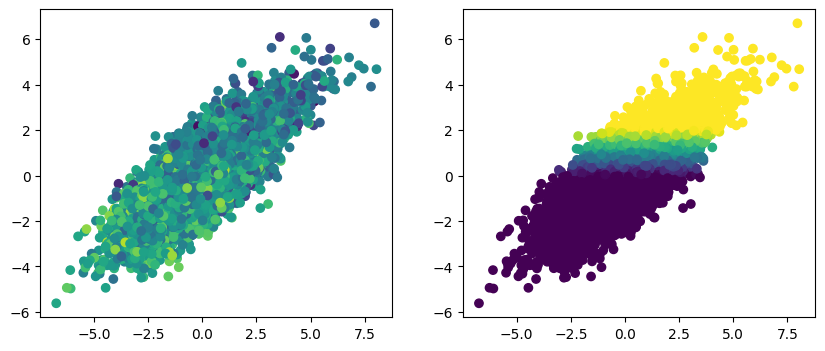

In [192]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

if ENV_NAME == 'walker':
    axs[0].scatter(decode_obs[..., 16].cpu(), decode_obs[..., 24].cpu(), c=rewards_pred.cpu())
    axs[1].scatter(decode_obs[..., 16].cpu(), decode_obs[..., 24].cpu(), c=decode_rewards.cpu())
    # axs[0].scatter(encode_obs[..., 16].cpu(), encode_obs[..., 24].cpu(), c=encode_rewards.cpu(), edgecolor='red')
    
if ENV_NAME == 'cheetah':
    axs[0].scatter(decode_obs[..., 8].cpu(), decode_obs[..., 17].cpu(), c=rewards_pred.cpu())
    axs[1].scatter(decode_obs[..., 8].cpu(), decode_obs[..., 17].cpu(), c=decode_rewards.cpu())
    # axs[0].scatter(encode_obs[..., 8].cpu(), encode_obs[..., 17].cpu(), c=encode_rewards.cpu(), edgecolor='red')


# IQL:

In [193]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    """Generic MLP with Mish activation and LayerNorm."""
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        layers = []
        prev_dim = input_dim

        # Add hidden layers with Mish activation and LayerNorm
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.Mish())
            # layers.append(nn.LayerNorm(hidden_dim))
            prev_dim = hidden_dim  # Update input size for next layer
        
        # Final output layer
        layers.append(nn.Linear(prev_dim, output_dim))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class ValueCritic(nn.Module):
    def __init__(self, obs_dim, hidden_dims):
        super().__init__()
        self.model = MLP(obs_dim, hidden_dims, output_dim=1)

    def forward(self, x):
        return self.model(x)


class Critic(nn.Module):
    def __init__(self, obs_dim, action_dim, hidden_dims):
        super().__init__()

        self.model1 = MLP(obs_dim + action_dim, hidden_dims, output_dim=1)
        self.model2 = MLP(obs_dim + action_dim, hidden_dims, output_dim=1)

    def forward(self, x, action):
        x = torch.cat((x, action), dim=-1)
        
        q1 = self.model1(x)
        q2 = self.model2(x)
        
        return q1, q2



class Actor(nn.Module):
    def __init__(self, input_dim, action_dim, hidden_dims, init_std=0.0):
        super().__init__()
        self.model = MLP(input_dim, hidden_dims, output_dim=action_dim)  # MLP only predicts mean
        
        # Learnable log standard deviation (initialized to `init_std`)
        self.log_std = nn.Parameter(torch.ones(action_dim) * init_std)

    def forward(self, x, temperature=1.0):
        mean = self.model(x)  # Predict action mean

        log_std = torch.clip(self.log_std, -20, 2)
        mean = torch.clip(mean, -5, 5)

        return torch.distributions.Normal(
            mean, 
            torch.exp(log_std)*temperature
        )


from torch.optim.lr_scheduler import CosineAnnealingLR
import copy


class IQL(nn.Module):
    def __init__(self, state_dim, action_dim, w_dim=128):
        super(IQL, self).__init__()
        self.obs_len = state_dim
                
        self.critic = Critic(w_dim + state_dim, action_dim, hidden_dims=[256, 256])
        self.target_critic = copy.deepcopy(self.critic)
        for param in self.target_critic.parameters():
            param.requires_grad = False
        
        self.value = ValueCritic(w_dim + state_dim, hidden_dims=[256, 256])        
        self.actor = Actor(w_dim + state_dim, action_dim, hidden_dims=[256, 256])
        
        self.critic_optim = torch.optim.Adam(self.critic.parameters(), lr=0.003)
        self.value_optim = torch.optim.Adam(self.value.parameters(), lr=0.003)
        self.actor_optim = torch.optim.Adam(self.actor.parameters(), lr=0.003)
        self.actor_lr_schedule = CosineAnnealingLR(self.actor_optim, 100000)
        
        
    def get_value(self, w, obs):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.value(w_and_obs)

    def get_critic(self, w, obs, actions):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.critic(w_and_obs, actions)
    
    def get_target_critic(self, w, obs, actions):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.target_critic(w_and_obs, actions)

    def get_actor(self, w, obs, temperature=1.0):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.actor(w_and_obs, temperature)
    
    
    
# def update_target_critic(critic, target_critic, tau):

#     critic_state_dict = critic.state_dict()
#     target_critic_state_dict = target_critic.state_dict()

#     for key in critic_state_dict:
#         target_critic_state_dict[key] = tau * critic_state_dict[key] + (1 - tau) * target_critic_state_dict[key]

#     target_critic.load_state_dict(target_critic_state_dict)
    
    
def update_target_critic(source, target, alpha):
    for target_param, source_param in zip(target.parameters(), source.parameters()):
        target_param.data.mul_(1. - alpha).add_(source_param.data, alpha=alpha)
    
    
def expectile_loss(adv, diff, expectile=0.7):
    weight = torch.where(
        adv >= 0, 
        torch.tensor(expectile, dtype=adv.dtype), 
        torch.tensor(1 - expectile, dtype=adv.dtype)
    )
    return weight * (diff ** 2)


def smooth_and_downsample(losses, smoothing=0.9, max_points=100):
    if not losses: return []
    smoothed = [losses[0]]
    for loss in losses[1:]:
        smoothed.append(smoothing * smoothed[-1] + (1 - smoothing) * loss)
    downsample = max(1, len(smoothed) // max_points)  # Ensure at least 1
    return smoothed[::downsample]

In [194]:
def get_iql_training_data(batch_size, num_states):

    trajectory_idx = torch.randint(0, num_trajectories, (batch_size*num_states,))
    state_idx = torch.randint(0, len_trajectory, (batch_size*num_states,)) % (len_trajectory - 1)

    states = dataset_trajectories[trajectory_idx, state_idx].reshape(batch_size, num_states, obs_dim)
    next_states = dataset_trajectories[trajectory_idx, state_idx+1].reshape(batch_size, num_states, obs_dim)
    actions = dataset_actions[trajectory_idx, state_idx].reshape(batch_size, num_states, ACTION_DIM)
    masks = ~dataset_timeouts[trajectory_idx, state_idx+1].reshape(batch_size, num_states, 1)
    
    return {
        'states': states.to(device),
        'actions': actions.to(device),
        'next_states': next_states.to(device),
        'masks': masks.to(device),
    }

In [208]:
def get_reward(reward_params, random_states):

    assert len(reward_params.shape) == 2
    assert len(random_states.shape) == 3
    assert reward_params.shape[0] == random_states.shape[0]
    
    all_rewards = torch.zeros((random_states.shape[0], random_states.shape[1]), device=device)

    for b in range(reward_params.shape[0]):
        param = reward_params[b]
        x = random_states[b].unsqueeze(0)
        if (param[0] == 2):
            rewards, _ = mlp_rewards(obs=x, param_id=param[1].reshape(1, 1).repeat(x.shape[0], 1).long())
        elif (param[0] == 1):
            rewards, _ = linear_rewards(obs=x, param_id=param[1].reshape(1, 1).repeat(x.shape[0], 1).long())
        elif (param[0] == 0):
            rewards, _ = goal_rewards(obs=x, goals=param[1:obs_dim+1].unsqueeze(0).repeat(x.shape[0], 1))
        
        all_rewards[b] = rewards.float()

    return all_rewards



def get_reward_RG(reward_params, mask, random_states):
    """
    reward_params: (batch_size, z_dim)
    random_states: (batch_size, num_states, obs_dim)
    """

    assert len(reward_params.shape) == 2
    assert len(random_states.shape) == 3
    assert reward_params.shape[0] == random_states.shape[0]
    
    batch_size, num_random_samples, _ = random_states.shape
    
    with torch.no_grad():
        
        mask = mask.unsqueeze(1).repeat(1, num_random_samples, 1).to(random_states.device)
        
        masked_random_states = random_states * mask
        
        rewards = reward_generator.get_reward(
            masked_random_states.reshape(-1, obs_dim), 
            reward_params.unsqueeze(1).repeat(1, num_random_samples, 1).reshape(-1, 128)
        ).reshape(batch_size, num_random_samples)
    
    return rewards

In [196]:
iql_agent = IQL(state_dim=STATE_DIM - AUX_DIM, action_dim=ACTION_DIM).to(device)
# iql_agent.load_state_dict(torch.load('shared_models/iql_agent.pth'))

actor_losses = []
v_losses, q_losses = [], []
mse_errors = []
stds = []

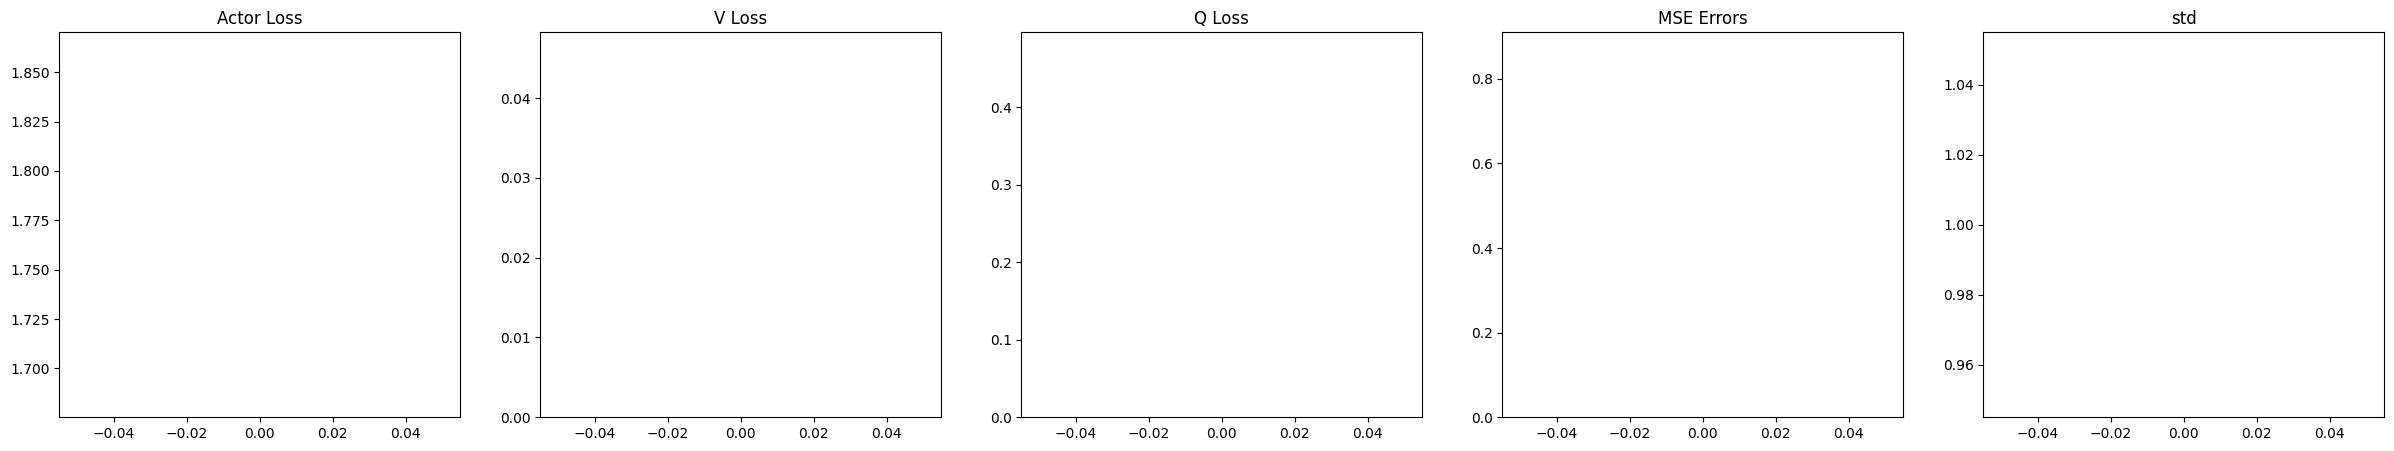

  0%|          | 0/100000 [00:00<?, ?it/s]


In [211]:
config = {
    'expectile': 0.8,
    'temperature': 3.0,
    'discount': 0.99,
    'tau': 0.005,
}

iql_batch_size = 32
iql_num_states = 512


for timestep in tqdm(range(100000)):

    
    reward_params, random_states, random_states_rewards, mask = sample_reward_function_fre_RG(batch_size=iql_batch_size, num_random_samples=128)
    encode_obs = random_states[:, :128, :].to(device)
    encode_rewards = random_states_rewards[:, :128, None].to(device)
    reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)
    
    
    batch = get_iql_training_data(
        batch_size=iql_batch_size, 
        num_states=iql_num_states
    )

    
    
    with torch.no_grad():
        w_mean, _ = fre_network.get_transformer_encoding(reward_state_pairs)   
        # w_mean = torch.zeros_like(w_mean) ############################################################################### !!!!!!!!!
        
        batch['rewards'] = get_reward_RG(reward_params, mask, random_states=batch['states']).unsqueeze(-1) ######## !!!!!!!!!
        # batch['rewards'] = benchmarks[3][0](batch['states'].flatten(0, 1).unsqueeze(0), 2).reshape(iql_batch_size, iql_num_states, 1)
    
    

    # Implicit Q-Learning 
    
    if ENV_NAME == 'cheetah':
        batch['states'] = batch['states'][..., :-1]
        batch['next_states'] = batch['next_states'][..., :-1]
    elif ENV_NAME == 'walker':
        batch['states'] = batch['states'][..., :-3]
        batch['next_states'] = batch['next_states'][..., :-3]
        

    
    
    
    w_target = w_mean.unsqueeze(1).repeat(1, batch['states'].shape[1], 1)
    
    with torch.no_grad():
        
        target_q1, target_q2 = iql_agent.get_target_critic(w_target, batch['states'], batch['actions'])
        target_q1, target_q2 = target_q1.detach(), target_q2.detach()
        target_q = torch.minimum(target_q1, target_q2)
        next_v = iql_agent.get_value(w_target, batch['next_states']).detach()
    
    
    # Value Loss: Update V towards expectile of min(q1, q2).
    
    v = iql_agent.get_value(w_target, batch['states'])
    adv = target_q - v
    v_loss = expectile_loss(adv, adv, config['expectile'])
    v_loss = v_loss.mean()

    iql_agent.value.zero_grad(set_to_none=True)
    v_loss.backward()
    iql_agent.value_optim.step()

    # Critic Loss. Update Q = r #############################
    targets = batch['rewards'] + config['discount'] * batch['masks'] * next_v

    q1, q2 = iql_agent.get_critic(w_target, batch['states'], batch['actions'])
    q_loss = ((q1 - targets).pow(2).mean() + (q2 - targets).pow(2).mean()) / 2
    q_loss = q_loss
    
    iql_agent.critic.zero_grad(set_to_none=True)
    q_loss.backward()
    iql_agent.critic_optim.step()

    # if timestep % 10 == 0:
    update_target_critic(iql_agent.critic, iql_agent.target_critic, config['tau'])

    value_loss = v_loss + q_loss
    value_info = {
        'v_loss': v_loss,
        'q_loss': q_loss,
        'v': v.mean(),
        'q': torch.minimum(q1, q2).mean(),
    }


    # Actor Loss ############################################


    actions = batch['actions']
    exp_a = torch.exp(adv.detach() * config['temperature']).clamp(max=100)
    
    dist = iql_agent.get_actor(w_target, batch['states'])
    log_probs = dist.log_prob(actions)
    actor_loss = -(exp_a * log_probs).mean()
    
    iql_agent.actor.zero_grad(set_to_none=True)
    actor_loss.backward()
    iql_agent.actor_optim.step()
    iql_agent.actor_lr_schedule.step()
    
    
    std = dist.stddev.mean()
    mse_error = ((dist.loc - batch['actions'])**2).mean()
    
    actor_info = {
        'actor_loss': actor_loss,
        'std': std,
        'adv': adv.mean(),
        'mse_error': mse_error,
    }

    ########################################################################################
    

    
    
    
    actor_losses.append(actor_loss.item())
    v_losses.append(v_loss.item())
    q_losses.append(q_loss.item())
    mse_errors.append(mse_error.item())
    stds.append(std.item())
    
    if timestep % 100 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 5, figsize=(30, 5))
        
        axs[0].plot(smooth_and_downsample(actor_losses))
        axs[1].set_ylim(0,max(actor_losses[-100:]))
        axs[0].set_title("Actor Loss")
        
        axs[1].plot(smooth_and_downsample(v_losses))
        axs[1].set_ylim(0,max(v_losses[-100:]))
        axs[1].set_title("V Loss")
        
        axs[2].plot(smooth_and_downsample(q_losses))
        axs[2].set_ylim(0,max(q_losses[-100:]))
        axs[2].set_title("Q Loss")
        
        axs[3].plot(smooth_and_downsample(mse_errors))
        axs[3].set_ylim(0,max(mse_errors[-100:]))
        axs[3].set_title("MSE Errors")
        
        axs[4].plot(smooth_and_downsample(stds))
        axs[4].set_title("std")
        
        plt.show()
        
    break

In [226]:
reward_params, random_states, random_states_rewards, mask = sample_reward_function_fre_RG(batch_size=1, num_random_samples=10_000)

batch = get_iql_training_data(
    batch_size=1, 
    num_states=10_000
)

with torch.no_grad():
    batch['rewards'] = get_reward_RG(reward_params, mask, random_states=batch['states']).unsqueeze(-1)

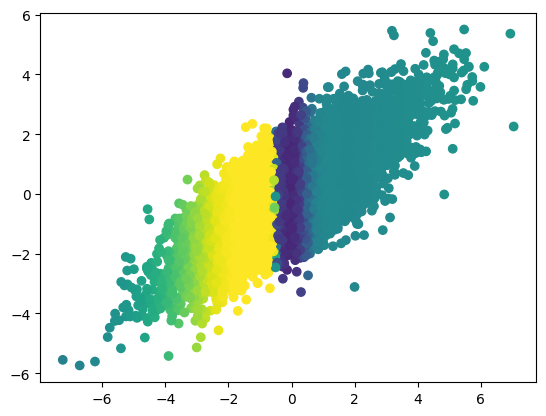

In [227]:
plt.scatter(random_states[..., 8].cpu(), random_states[..., 17].cpu(), c=random_states_rewards.cpu(), vmin=-1, vmax=1)

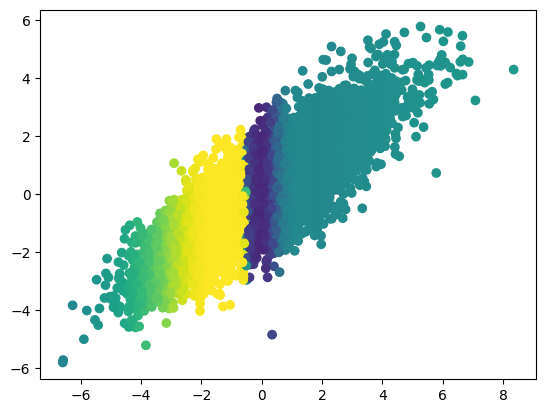

In [228]:
plt.scatter(batch['states'][..., 8].cpu(), batch['states'][..., 17].cpu(), c=batch['rewards'].cpu(), vmin=-1, vmax=1)

# Benchmark:

In [229]:
import matplotlib.patches as patches
        
        
def get_eval_rewards(eval_z, to_keep:list=None): 
    states = dataset_trajectories[::50, :1000:10].reshape(-1, obs_dim)
    states = states.to(device)

    res = []
    for i in range(len(eval_z)):
        
        zi = eval_z[i].unsqueeze(0)
        with torch.no_grad():
            x = states.unsqueeze(0)
            if to_keep is not None:
                x = torch.zeros_like(x)
                x[..., to_keep] = states[..., to_keep]
            r = fre_network.get_reward_pred(zi, x).cpu()
            
            res.append(r)
    
    res = torch.stack(res).squeeze(-1)
    
    return x.cpu(), res.cpu()

In [131]:
def timestep2obs(timestep):
    obs = np.concatenate([v if len(v.shape) != 0 else v.reshape(-1) for k, v in timestep.observation.items()])
    return obs


def run_test(fre_network, iql_agent, benchmark_id, num_evals, num_eval_anchors):


    benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]

    produced_trajectories = []
    produced_trajectories_physics = []
    
    for _ in range(num_evals):
        

        reward_params, encode_obs, random_states_rewards = sample_reward_function_fre(batch_size=1, num_random_samples=num_eval_anchors)
        encode_obs = encode_obs.to(device)


        encode_rewards = benchmark_reward_function(encode_obs.cpu(), benchmark_param).unsqueeze(-1).to(device)

        reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)

        with torch.no_grad():
            w_mean, _ = fre_network.get_transformer_encoding(reward_state_pairs)  
            w_mean = torch.zeros_like(w_mean)
            
            
            
        timestep = env.reset()        
        state = timestep2obs(timestep)
        state = normalize_dataset_coords(state)
    
        produced_trajectory = []   
        produced_trajectory_physics = [] 


        for step in tqdm(range(1000)):
            
            physics = env.physics.get_state()
            
            produced_trajectory_physics.append(physics)
            
            if ENV_NAME == 'walker':
                horizontal_velocity = env.physics.horizontal_velocity()
                torso_upright = env.physics.torso_upright()
                torso_height = env.physics.torso_height()
                aux = np.array([horizontal_velocity, torso_upright, torso_height])

            elif ENV_NAME == 'cheetah':
                horizontal_velocity = env.physics.speed()
                aux = np.array([horizontal_velocity])
            
            observation_aux = np.concatenate([state, aux])
            
            produced_trajectory.append(observation_aux)
            
            
            with torch.no_grad():
                tensor_state = torch.tensor(state).reshape(1, -1).to(device).float()
                
                if ENV_NAME == 'cheetah':
                    tensor_state[..., -1:] = 0
                elif ENV_NAME == 'walker':
                    tensor_state[..., -3:] = 0
                
                dist = iql_agent.get_actor(w_mean, tensor_state)
                action = dist.loc.cpu()
                action = np.array(action[0]).clip(-1, 1)

            timestep = env.step(action)
            
            next_state = timestep2obs(timestep)
            state = normalize_dataset_coords(next_state)
            
            
        produced_trajectory = np.stack(produced_trajectory)
        produced_trajectory_physics = np.stack(produced_trajectory_physics)
                
        produced_trajectories.append(produced_trajectory)
        produced_trajectories_physics.append(produced_trajectory_physics)
    
    produced_trajectories = np.stack(produced_trajectories)
    produced_trajectories_physics = np.stack(produced_trajectories_physics)
    

    return produced_trajectories, produced_trajectories_physics, w_mean



100%|██████████| 1000/1000 [00:00<00:00, 2751.63it/s]


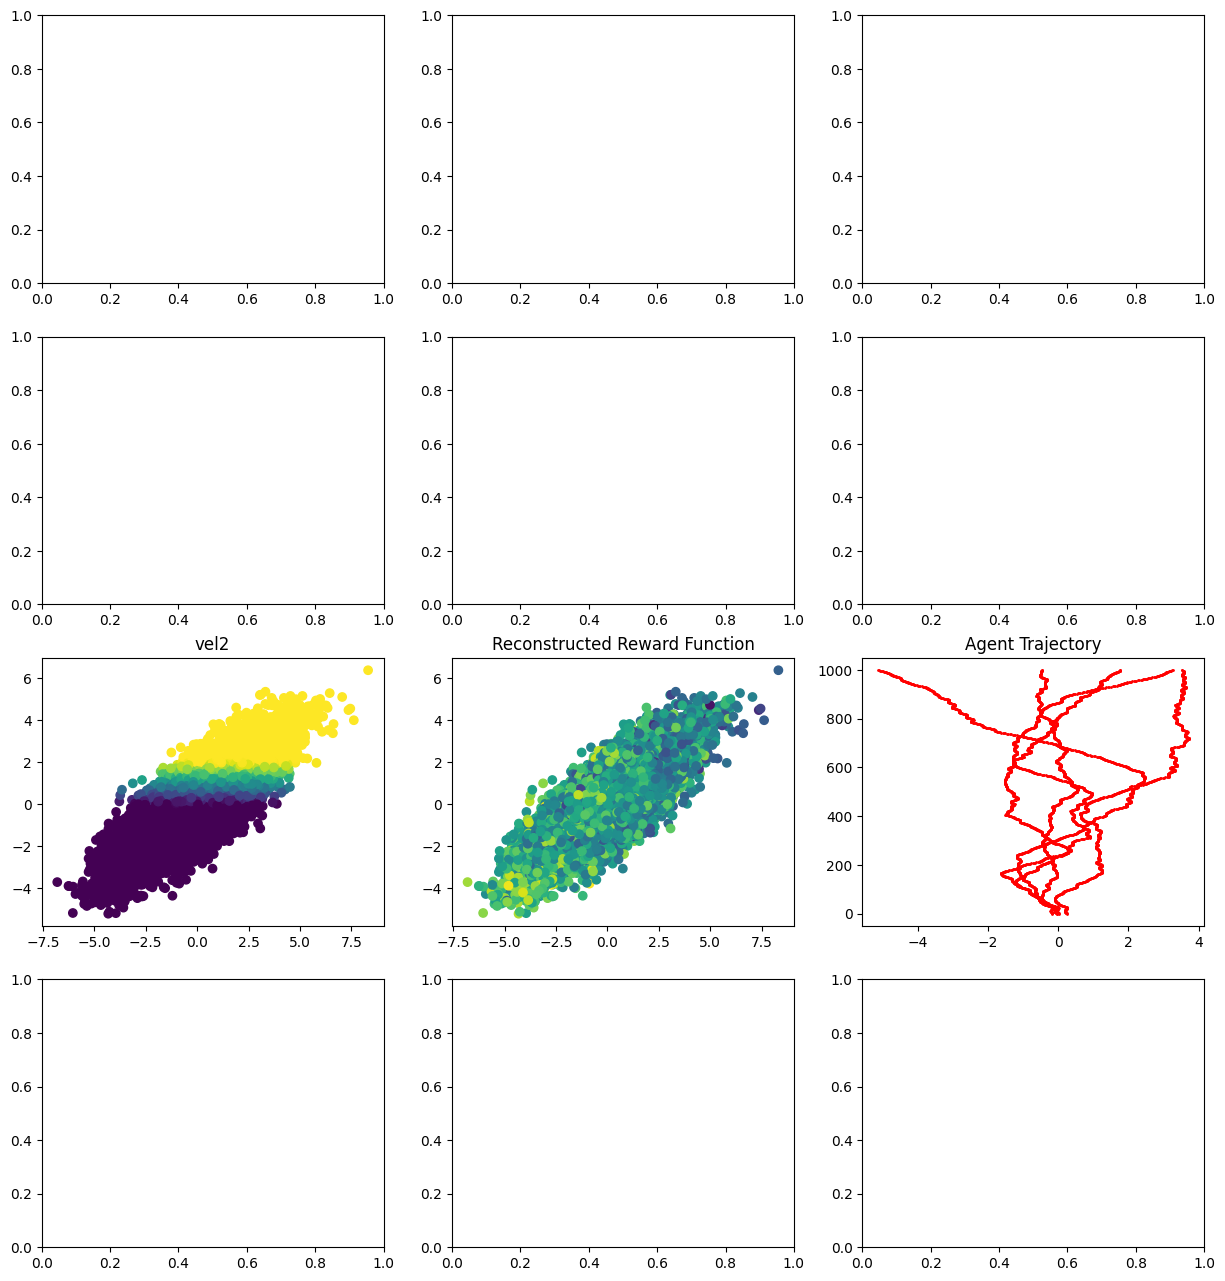

In [57]:
num_evals = 5
fig, axs = plt.subplots(len(benchmarks), 3, figsize=(15, len(benchmarks)*4))

all_produced_trajectories = []

for benchmark_id in range(len(benchmarks)):

    benchmark_id = 2
    
    benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]
    
    produced_trajectory, produced_trajectory_physics, w_mean = run_test(fre_network, iql_agent, benchmark_id=benchmark_id, num_evals=num_evals, num_eval_anchors=128)
    

    eval_states, eval_rewards = get_eval_rewards(w_mean)
    real_eval_rewards = benchmark_reward_function(eval_states, benchmark_param)


    if ENV_NAME == 'cheetah':
        axs[benchmark_id, 0].scatter(eval_states[..., 8], eval_states[..., 17], c=real_eval_rewards)
        axs[benchmark_id, 1].scatter(eval_states[..., 8], eval_states[..., 17], c=eval_rewards)
        axs[benchmark_id, 2].scatter(
            produced_trajectory_physics[..., 0],
            torch.arange(1000).unsqueeze(1).repeat(1, num_evals).T,
            c='red', s=1
        )
    elif ENV_NAME == 'walker':
        axs[benchmark_id, 0].scatter(eval_states[..., 16], eval_states[..., 24], c=real_eval_rewards)
        axs[benchmark_id, 1].scatter(eval_states[..., 16], eval_states[..., 24], c=eval_rewards)
        axs[benchmark_id, 2].scatter(
            produced_trajectory_physics[..., 1],
            torch.arange(1000).unsqueeze(1).repeat(1, num_evals).T,
            c='red', s=1
        )
    
    
    # plt.title(f'{benchmark_test_label}')
    axs[benchmark_id, 0].set_title(f'{benchmark_test_label}')
    axs[benchmark_id, 1].set_title(f'Reconstructed Reward Function')
    axs[benchmark_id, 2].set_title(f'Agent Trajectory')
    
    
    all_produced_trajectories.append(produced_trajectory)
    
    break
    
plt.show()


all_produced_trajectories = np.stack(all_produced_trajectories)

In [167]:
for benchmark_id in range(len(benchmarks)):

    benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]
    

    trajectory_states = torch.tensor(all_produced_trajectories[benchmark_id]).reshape(1, -1, STATE_DIM)
    trajectory_states_rewards = benchmark_reward_function(trajectory_states, benchmark_param).float()
    trajectory_states_rewards = trajectory_states_rewards.reshape(
        all_produced_trajectories.shape[1],
        all_produced_trajectories.shape[2],
    )
    trajectory_rewards = trajectory_states_rewards.sum(dim=-1)
    
    # if 'goal' in benchmark_test_label: 
    #     trajectory_rewards = torch.where(trajectory_rewards != -all_produced_trajectories.shape[2], 1., 0.)
        
    print(benchmark_test_label, ':')
    print('\tRewards:', trajectory_rewards.tolist())
    print('\tmean:', trajectory_rewards.mean().item())
    print('\tstd:', trajectory_rewards.std().item())

vel0.1 :
	Rewards: [193.698486328125, 172.84397888183594, 192.30654907226562, 174.16893005371094, 288.591552734375]
	mean: 204.3218994140625
	std: 48.11096954345703
vel1 :
	Rewards: [191.9730224609375, 186.527099609375, 174.25213623046875, 179.01681518554688, 195.0112762451172]
	mean: 185.3560791015625
	std: 8.68708610534668
vel4 :
	Rewards: [171.33657836914062, 176.5977783203125, 168.56517028808594, 175.65455627441406, 174.32156372070312]
	mean: 173.29513549804688
	std: 3.3066747188568115
vel8 :
	Rewards: [167.92828369140625, 166.8134002685547, 170.10641479492188, 169.17724609375, 167.70880126953125]
	mean: 168.34683227539062
	std: 1.2960901260375977


/tmp/ipykernel_440258/22890144.py:84: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(rew[..., 0])


In [172]:
ids = dataset['observations'][:, :, 24].mean(axis=-1).argsort()[-10:]

In [173]:
trajectory_states_rewards = benchmark_reward_function(
    dataset_trajectories[ids].flatten(0, 1).unsqueeze(0),
    # torch.tensor(all_produced_trajectories[0]),
    8
).float()

/tmp/ipykernel_440258/22890144.py:84: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(rew[..., 0])


In [174]:
trajectory_states_rewards.reshape(10, 1000).sum(axis=-1)

tensor([548.3525, 551.6653, 562.6894, 595.7260, 602.7870, 660.7023, 656.5394,
        663.8695, 668.7409, 750.0712])

ValueError: x and y must be the same size

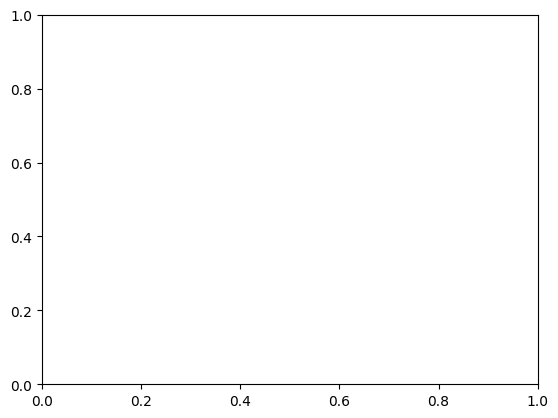

In [175]:
plt.scatter(
    dataset['physics'][ids, :, 1],
    torch.arange(1000).unsqueeze(1).repeat(1, 5).T,
    # torch.arange(1000),
    c='red', s=1
)